# Segmentasi Pelanggan

## Metodologi

1. **Persiapan Data dan Library**: Memuat dataset dan library yang diperlukan.
2. **Penentuan Tanggal Acuan**: Menetapkan titik waktu referensi untuk perhitungan `recency`.
3. **Penghitungan Metrik RFM**: Melakukan agregasi data untuk mendapatkan nilai `recency`, `frequency`, dan `monetary`.
4. **Pemberian Skor RFM**: Mengelompokkan pelanggan ke dalam kuantil skor 1-5.
5. **Segmentasi Pelanggan**: Memetakan kombinasi skor ke dalam label segmen bisnis.
6. **Visualisasi Distribusi**: Menampilkan komposisi segmen menggunakan Treemap.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import numpy as np
import squarify
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('data/superstore_2017.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')

## Menentukan Tanggal Acuan

Variabel ini digunakan untuk menghitung metrik `recency`.

In [2]:
snapshot_date = df['order_date'].max() + pd.to_timedelta(1, unit='day')

## Menghitung RFM

Pada tahap ini, dilakukan agregasi data berdasarkan `customer_id` untuk menghasilkan tiga metrik utama RFM:
- **Recency**: Menghitung selisih hari antara `snapshot_date` dengan tanggal transaksi terakhir masing-masing pelanggan.
- **Frequency**: Menghitung total pesanan unik yang dilakukan oleh setiap pelanggan.
- **Monetary**: Menghitung total pendapatan yang dihasilkan oleh setiap pelanggan.

In [3]:
df_RFM = df.groupby('customer_id').agg(recency = ('order_date', lambda x: (snapshot_date - x.max()).days),
                                       frequency = ('order_id', 'nunique'),
                                       monetary = ('sales', 'sum'))

df_RFM

,recency,frequency,monetary
customer_id,,,
AA-10315,185,1,374.480
AA-10375,20,2,206.732
AA-10480,260,1,15.552
AA-10645,56,1,12.960
AB-10060,55,4,2936.264
...,...,...,...
XP-21865,44,4,449.312
YC-21895,5,1,750.680
YS-21880,10,5,5340.264


## Pemberian Skor RFM

Tahap ini dilakukan untuk membagi pelanggan ke dalam 5 kelompok (kuantil) berdasarkan setiap metrik.
- **R_score**: Skor 5 diberikan kepada pelanggan yang baru melakukan transaksi, sedangkan skor 1 untuk pelanggan yang sudah lama tidak melakukan transaksi.
- **F_score**: Skor 5 diberikan kepada pelanggan dengan jumlah transaksi terbanyak, sedangkan skor 1 untuk pelanggan yang jarang melakukan transaksi.
- **M_score**: Skor 5 diberikan kepada pelanggan dengan nilai transaksi tertinggi, sedangkan skor 1 untuk pelanggan dengan nilai transaksi terendah.

In [4]:
df_RFM['R_score'] = pd.qcut(df_RFM['recency'].rank(method='first'), q=5, labels=[5, 4, 3, 2, 1]).astype(int)
df_RFM['F_score'] = pd.qcut(df_RFM['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
df_RFM['M_score'] = pd.qcut(df_RFM['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

df_RFM

,recency,frequency,monetary,R_score,F_score,M_score
customer_id,,,,,,
AA-10315,185,1,374.480,1,1,2
AA-10375,20,2,206.732,5,2,2
AA-10480,260,1,15.552,1,1,1
AA-10645,56,1,12.960,3,1,1
AB-10060,55,4,2936.264,3,5,5
...,...,...,...,...,...,...
XP-21865,44,4,449.312,3,5,3
YC-21895,5,1,750.680,5,2,3
YS-21880,10,5,5340.264,5,5,5


## Segmentasi Pelanggan

Pada tahap ini, pelanggan dikategorikan ke dalam segmen spesifik berdasarkan kombinasi `R_score`, `F_score`, dan `M_score`. Pengelompokan ini menggunakan fungsi `np.select` untuk memetakan logika bisnis ke dalam label segmen sebagai berikut:
- **Champions**: Pelanggan terbaik yang baru saja bertransaksi, sering berbelanja, dan memiliki nilai transaksi tinggi.
- **Loyal Customers**: Pelanggan yang cukup aktif bertransaksi.
- **New / Promising**: Pelanggan yang baru saja bergabung atau bertransaksi namun belum memiliki frekuensi belanja yang tinggi.
- **At Risk**: Pelanggan yang sudah lama tidak bertransaksi, namun sebelumnya merupakan pelanggan yang berharga.
- **Lost**: Pelanggan yang kemungkinan besar sudah tidak aktif lagi.

In [5]:
conditions = [(df_RFM['R_score'] >= 4) & (df_RFM['F_score'] >= 4) & (df_RFM['M_score'] >= 4),
              (df_RFM['R_score'] >= 3) & (df_RFM['F_score'] >= 3),
              (df_RFM['R_score'] >= 3) & (df_RFM['F_score'] <= 2),
              ((df_RFM['R_score'] <= 2) & (df_RFM['F_score'] >= 3)) |
              ((df_RFM['R_score'] <= 2) & (df_RFM['M_score'] >= 4)),
              (df_RFM['R_score'] <= 2) & (df_RFM['F_score'] <= 2)]

segments = ['Champions', 'Loyal Customers', 'New / Promising', 'At Risk', 'Lost']

df_RFM['segment'] = np.select(conditions, segments, default='Other')

df_RFM

,recency,frequency,monetary,R_score,F_score,M_score,segment
customer_id,,,,,,,
AA-10315,185,1,374.480,1,1,2,Lost
AA-10375,20,2,206.732,5,2,2,New / Promising
AA-10480,260,1,15.552,1,1,1,Lost
AA-10645,56,1,12.960,3,1,1,New / Promising
AB-10060,55,4,2936.264,3,5,5,Loyal Customers
...,...,...,...,...,...,...,...
XP-21865,44,4,449.312,3,5,3,Loyal Customers
YC-21895,5,1,750.680,5,2,3,New / Promising
YS-21880,10,5,5340.264,5,5,5,Champions


## Visualisasi Distribusi Segmen Pelanggan

Tahap ini bertujuan untuk memvisualisasikan komposisi dan dominasi setiap segmen pelanggan menggunakan Treemap.

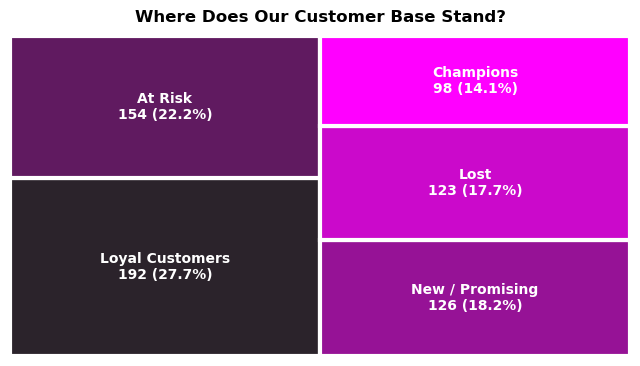

In [6]:
df_plot = df_RFM['segment'].value_counts()
labels = [f'{index}\n{values} ({(values / df_plot.sum()) * 100:.1f}%)' for index, values in zip(df_plot.index, df_plot.values)]
colors = sns.color_palette('dark:magenta', n_colors=5)

plt.figure(figsize=(7,4))
squarify.plot(sizes=df_plot.values, label=labels, color=colors, ec='white', lw=3,
              text_kwargs={'size':10,'weight':'bold','color':'white'})

title_dict = {'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'pad':10,
              'rotation':0,
              'alpha':1,
              'family':plt.rcParams['font.family']}

plt.title('Where Does Our Customer Base Stand?', **title_dict)

plt.tight_layout()
plt.axis(False)
plt.show()

## Penyimpanan Data Hasil Analisis

Pada tahap ini, `df_RFM` yang telah berisi metrik RFM dan segmen pelanggan disimpan ke dalam format CSV.

In [7]:
df_RFM.to_csv('data/RFM_dataset.csv', index=True)